In [1]:
# --- 1.librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib qt

In [36]:
# --- 2. Leer el archivo ---

## ARCHIVO
#file_path = "C:/Users/sofip/Blade/pruebas_gorra_miercoles_19_11/prueba_2_chris" #mie 19/11
#file_path = "C:/Users/sofip/Blade/pruebas_gorra_miercoles_19_11/registro_1_chris.log"

# file_force = "C:/Users/sofip/Blade/Pinprick interface serial/windows-amd64/umbrales_sofi"
file_force = "C:/Users/sofip/Blade/force_data/umbrales_sofi_4" # velocidad de 2.5 mm/s 
file_force_2 = "C:/Users/sofip/Blade/force_data/umbrales_sofi_2" # velocidad de 2.5 mm/s 

file_eeg_events = "C:/Users/sofip/Blade/events_10_2.csv"

In [3]:
df = pd.read_csv(file_force, header=None, sep=',',  names=["force", "millis","time"])
print(df)

         force    millis      time
0      -1.0E-4   85086.0  14:35:35
1      -1.0E-4   85188.0  14:35:36
2      -1.0E-4   85288.0  14:35:36
3      -1.0E-4   85388.0  14:35:36
4      -1.0E-4   85489.0  14:35:36
...        ...       ...       ...
16508   0.0062  204601.0  14:37:35
16509   0.0062  204701.0  14:37:35
16510   0.0064  204801.0  14:37:35
16511   0.0061  204902.0  14:37:35
16512   0.0061  205001.0  14:37:35

[16513 rows x 3 columns]


### graficas thresholds

In [37]:
# 1. Cargar y procesar el archivo mixto (datos + marcas)
force_data = []
markers = []

with open(file_force, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        if '\t' in line:
            parts = line.split('\t')
            # Las marcas de fuerza tienen 3 partes: etiqueta, valor, ms
            if len(parts) == 3:
                markers.append({'label': parts[0], 'val': float(parts[1]), 'ms': int(parts[2])})
            else: # Marcas de tiempo (inicial/final) tienen 2 partes
                markers.append({'label': parts[0], 'ms': int(parts[1])})
        else:
            parts = line.split(',')
            try:
                force_data.append({'ms': int(parts[1]), 'force': float(parts[0])})
            except: continue

df_force = pd.DataFrame(force_data)

# 2. Organización de resultados para el promedio
res = {
    'Detección': [m['val'] for m in markers if 'deteccion' in m['label'].lower()],
    'Umbral': [m['val'] for m in markers if 'umbral' in m['label'].lower()],
    'Tolerancia': [m['val'] for m in markers if 'tolerancia' in m['label'].lower()]
}

# 3. Impresión de tabla de resultados y promedios
print("-" * 70)
print(f"{'Tipo':<12} | {'E1':<8} | {'E2':<8} | {'E3':<8} | {'Promedio':<8}")
print("-" * 70)

for tipo, valores in res.items():
    if len(valores) >= 3:
        promedio = sum(valores[:3]) / 3
        print(f"{tipo:<12} | {valores[0]:.4f} | {valores[1]:.4f} | {valores[2]:.4f} | {promedio:.4f}")
    else:
        print(f"{tipo:<12} | Datos insuficientes (se encontraron {len(valores)})")
print("-" * 70)

# 4. Generación de Subplots (Visualización)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.6)

starts = [m for m in markers if 'marca inicial' in m['label']]
ends = [m for m in markers if 'tolerancia' in m['label']]

for i in range(min(len(starts), 3)):
    ax = axes[i]
    t_0 = starts[i]['ms']
    t_f = ends[i]['ms'] + 200
    
    seg = df_force[(df_force['ms'] >= t_0) & (df_force['ms'] <= t_f)].copy()
    seg['t_rel'] = seg['ms'] - t_0
    
    ax.plot(seg['t_rel'], seg['force'], color='black', label='Fuerza')
    
    # Dibujar líneas verticales
    ensayo_marks = [m for m in markers if t_0 <= m['ms'] <= t_f]
    for m in ensayo_marks:
        label = m['label'].lower()
        rel_x = m['ms'] - t_0
        
        if 'deteccion' in label: color = 'blue'
        elif 'umbral' in label: color = 'red'
        elif 'tolerancia' in label: color = 'green'
        else: continue
        
        ax.axvline(x=rel_x, color=color, linestyle='--', alpha=0.6)
        ax.text(rel_x, ax.get_ylim()[1]*0.9, m['label'], color=color, rotation=90, va='top', ha='right', fontsize=9)

    ax.set_title(f"Ensayo {i+1}")
    ax.set_ylabel("Fuerza")
    ax.grid(True, alpha=0.2)

plt.show()

----------------------------------------------------------------------
Tipo         | E1       | E2       | E3       | Promedio
----------------------------------------------------------------------
Detección    | -0.0001 | 0.0133 | 0.0090 | 0.0074
Umbral       | 0.1496 | 0.2110 | 0.1439 | 0.1682
Tolerancia   | 0.1923 | 0.2785 | 0.2151 | 0.2286
----------------------------------------------------------------------


In [33]:
from scipy.signal import savgol_filter

# ... (Tu código de lectura del archivo y dataframe queda igual) ...

# 4. Generación de Subplots (FUERZA Y PENDIENTE SUPERPUESTAS EN KG)
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
plt.subplots_adjust(hspace=0.4)

starts = [m for m in markers if 'marca inicial' in m['label']]
ends = [m for m in markers if 'tolerancia' in m['label']]

for i in range(min(len(starts), 3)):
    ax1 = axes[i]
    t_0 = starts[i]['ms']
    t_tol = ends[i]['ms']
    
    # Dibujamos la fuerza hasta 50ms después de tolerancia para ver el pico
    t_f = t_tol + 50 
    
    # 1. Segmento de Fuerza (Línea Negra)
    seg_force = df_force[(df_force['ms'] >= t_0) & (df_force['ms'] <= t_f)].copy()
    if seg_force.empty: continue
    seg_force['t_rel'] = seg_force['ms'] - t_0
    
    # 2. Segmento de Derivada (Corte ESTRICTO en tolerancia)
    seg_deriv = df_force[(df_force['ms'] >= t_0) & (df_force['ms'] <= t_tol)].copy()
    seg_deriv['t_rel'] = seg_deriv['ms'] - t_0
    
    # Calculamos dt en segundos para toda la ventana
    dt_mean_sec = (seg_deriv['ms'].iloc[-1] - seg_deriv['ms'].iloc[0]) / (len(seg_deriv) - 1) / 1000.0
    
    # Parámetros del Filtro Savitzky-Golay
    window_length = 101
    if len(seg_deriv) < window_length:
        window_length = len(seg_deriv) // 2 * 2 + 1
        if window_length < 5: window_length = 5
        
    deriv_savgol = savgol_filter(seg_deriv['force'], window_length=window_length, polyorder=3, deriv=1, delta=dt_mean_sec)
    seg_deriv['deriv_smooth'] = deriv_savgol
    
    # --- GRAFICAR FUERZA (Eje Izquierdo) ---
    l1 = ax1.plot(seg_force['t_rel'], seg_force['force'], color='black', label='Fuerza (kg)', linewidth=2)
    ax1.set_ylabel("Fuerza (kg)", color='black', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='black')
    
    # --- GRAFICAR PENDIENTE (Eje Derecho) ---
    ax2 = ax1.twinx()
    l2 = ax2.plot(seg_deriv['t_rel'], seg_deriv['deriv_smooth'], color='orange', label='Pendiente (kg/s)', linewidth=2.5)
    ax2.set_ylabel("Pendiente (kg/s)", color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')
    
    # Ajustamos límite inferior de la pendiente para que no baje demasiado por el ruido
    y_min, y_max = ax2.get_ylim()
    ax2.set_ylim(bottom=-0.05, top=y_max*1.1) 
    
    # --- LÍNEAS VERTICALES ---
    ensayo_marks = [m for m in markers if t_0 <= m['ms'] <= t_tol]
    for m in ensayo_marks:
        label = m['label'].lower()
        rel_x = m['ms'] - t_0
        
        if 'deteccion' in label: color = 'blue'
        elif 'umbral' in label: color = 'red'
        elif 'tolerancia' in label: color = 'green'
        else: continue
        
        ax1.axvline(x=rel_x, color=color, linestyle='--', alpha=0.8, linewidth=1.5)
        ax1.text(rel_x, ax1.get_ylim()[1]*0.9, m['label'], color=color, rotation=90, va='top', ha='right', fontsize=10, fontweight='bold')

    ax1.set_title(f"Ensayo {i+1}: Fuerza vs. Pendiente de Crecimiento", fontsize=14)
    ax1.set_xlabel("Tiempo desde marca inicial (ms)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # --- LEYENDA COMBINADA ---
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
seg_deriv['deriv_smooth']

11547   NaN
11548   NaN
11549   NaN
11550   NaN
11551   NaN
         ..
16279   NaN
16280   NaN
16281   NaN
16282   NaN
16283   NaN
Name: deriv_smooth, Length: 4737, dtype: float64

### graficas evocados

In [18]:
mask_marcas = df["force"].astype(str).str.contains("marca", case=False, na=False)
df_marcas = df[mask_marcas].copy()
df_datos  = df[~mask_marcas].copy()

#print(df_datos)

# Indices donde hay marca
marcas_idx = df_marcas.index

# Para cada marca → tomar el timestamp de la fila anterior
df_marcas["timestamp_idx_ant"] = marcas_idx.map(lambda i: df.loc[i-1, "timestamp"])
df_marcas["force_ant"] = marcas_idx.map(lambda i: df.loc[i-1, "force"])
# filtro marcas iniciales
df_iniciales = df_marcas[df_marcas["force"].str.contains("inicial", case=False, na=False)]

#paso a numeric para poder graficar
df_iniciales["force_ant"] = pd.to_numeric(df_iniciales["force_ant"], errors="coerce")
df_iniciales["timestamp_idx_ant"] = pd.to_numeric(df_iniciales["timestamp_idx_ant"], errors="coerce")

df_datos["force"] = pd.to_numeric(df_datos["force"], errors="coerce")
df_datos["timestamp"] = pd.to_numeric(df_datos["timestamp"], errors="coerce")
print(len(df_iniciales))
print(df_iniciales)


40
               force  timestamp  timestamp_idx_ant  force_ant
6828   marca inicial        NaN       6.850132e+08     0.0054
7146   marca inicial        NaN       6.951676e+08     0.0058
7535   marca inicial        NaN       7.055238e+08     0.0146
7880   marca inicial        NaN       7.151124e+08     0.0087
8220   marca inicial        NaN       7.237238e+08     0.0123
8582   marca inicial        NaN       7.331238e+08     0.0105
8925   marca inicial        NaN       7.416238e+08     0.0155
9299   marca inicial        NaN       7.517260e+08     0.0114
9703   marca inicial        NaN       7.622238e+08     0.0105
10057  marca inicial        NaN       7.708238e+08     0.0078
10451  marca inicial        NaN       7.810379e+08     0.0136
10811  marca inicial        NaN       7.900269e+08     0.0065
11163  marca inicial        NaN       7.996251e+08     0.0076
11545  marca inicial        NaN       8.088238e+08     0.0068
11922  marca inicial        NaN       8.188238e+08     0.0086
12259

C:\Users\sofip\AppData\Local\Temp\ipykernel_25956\3075804242.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iniciales["force_ant"] = pd.to_numeric(df_iniciales["force_ant"], errors="coerce")
C:\Users\sofip\AppData\Local\Temp\ipykernel_25956\3075804242.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iniciales["timestamp_idx_ant"] = pd.to_numeric(df_iniciales["timestamp_idx_ant"], errors="coerce")


In [19]:
df_iniciales["timestamp_idx_ant"]/1e6

6828      685.013235
7146      695.167627
7535      705.523828
7880      715.112367
8220      723.723827
8582      733.123828
8925      741.623828
9299      751.726002
9703      762.223826
10057     770.823828
10451     781.037888
10811     790.026863
11163     799.625130
11545     808.823828
11922     818.823828
12259     826.523828
12652     838.123829
13010     847.923826
13374     857.626864
13757     868.923827
14096     877.723827
14451     887.611938
14813     896.923828
15171     907.623829
15528     916.523913
15870     925.513235
16217     934.323827
16588     945.211071
16920     953.423914
17258     962.123829
17636     971.925130
17979     981.125128
18341     990.737887
18717    1000.635042
19051    1009.034951
19393    1018.234951
19743    1027.434953
20085    1036.634951
20416    1046.134953
20769    1056.434953
Name: timestamp_idx_ant, dtype: float64

In [68]:
len(df_datos["time_s"])

21112

#### graficas

In [20]:

plt.figure()
plt.plot(df_datos['timestamp']/1e6,df_datos['force'])
plt.scatter(df_iniciales['timestamp_idx_ant']/1e6,df_iniciales['force_ant'], color='red')
plt.axhline(0.23,color='black')
plt.xlabel('timestamp (micro) / 1e6')
plt.ylim(0,0.3)


plt.figure()
plt.hist(df_iniciales['force_ant'], bins=50)
plt.xlabel("Fuerza donde se manda marca inicial (kg)")
plt.ylabel("Cantidad")
plt.title("Distribución de fuerzas → jitter")
plt.show()

#### sfreq?

In [21]:
df_datos["time_s"] = df_datos["timestamp"] / 1e6   # si ya está corregido 
df_datos["dt"] = df_datos["time_s"].diff()   # diferencia entre timestamps consecutivos en segundos
# print(df_datos["dt"]) 
fs_estimada = 1 / df_datos["dt"].mean()

df_datos["fs_inst"] = 1 / df_datos["dt"]
print(df_datos["fs_inst"])

plt.figure()
plt.hist(df_datos["dt"][1:], bins=50)
plt.xlabel("Diff entre datos (s)")
plt.ylabel("Cantidad")
plt.title("Distribución de diff (s) → jitter")
plt.show()

plt.figure()
plt.plot(df_datos["dt"][1:])
plt.title("Diff entre datos")
plt.ylabel("s")
plt.xlabel("Muestras")
plt.show()

plt.figure()
plt.plot(df_datos["fs_inst"])
plt.title("Frecuencia instantánea")
plt.ylabel("Hz")
plt.xlabel("Muestras")
plt.show()

0            NaN
1         9.9980
2        10.0002
3        10.0001
4        10.0015
          ...   
21187     9.9988
21188    10.0019
21189    10.0004
21190     9.9992
21191    10.0009
Name: fs_inst, Length: 21112, dtype: float64


#### Alinear marcas?

In [ ]:
eeg_time_s = eeg_events["sample"]/eeg_sfreq 
fuerza_time_s = df_iniciales["timestamp_idx_ant"]/1e6
primer_evento_eeg = eeg_time_s[0]
primer_evento_fuerza = fuerza_time_s.iloc[0]

delay = primer_evento_eeg - primer_evento_fuerza

print(f"Desfase entre EEG y fuerza: {delay:.4f} segundos")

df_iniciales["time_s_aligned"] = fuerza_time_s + delay

print(eeg_time_s)


Desfase entre EEG y fuerza: -646.3352 segundos
0      38.678
1      48.822
2      59.180
3      68.768
4      77.380
5      86.781
6      95.281
7     105.383
8     115.882
9     124.482
10    134.697
11    143.696
12    153.284
13    162.484
14    172.484
15    180.184
16    191.785
17    201.585
18    211.298
19    222.586
20    231.386
21    241.275
22    250.587
23    261.287
24    270.188
25    279.187
26    287.988
27    298.876
28    307.089
29    315.789
30    325.591
31    334.791
32    344.404
33    354.302
34    362.702
35    371.902
36    381.103
37    390.303
38    399.804
39    410.104
Name: sample, dtype: float64


C:\Users\sofip\AppData\Local\Temp\ipykernel_25956\3455668712.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iniciales["time_s_aligned"] = fuerza_time_s + delay


In [ ]:
plt.plot(eeg_time_s, np.ones_like(eeg_time_s), "o", label="EEG")
plt.plot(df_iniciales["time_s_aligned"], np.ones_like(df_iniciales["time_s_aligned"]), "x", label="Fuerza")
plt.legend()
plt.yticks([])
plt.xlabel("Tiempo (s)")
plt.title("Comparación visual de eventos EEG vs Fuerza")
plt.show()


### para el registro del mie 19/11

In [ ]:
df = pd.read_csv(file_path, header=None,  names=["force", "timestamp"])
print(df.head())

mask_marcas = df["force"].astype(str).str.contains("marca", case=False, na=False)
df_marcas = df[mask_marcas].copy()
df_datos  = df[~mask_marcas].copy()
# Extraemos SIEMPRE los números de la columna fuerza
import re

df_marcas["force_real"] = df_marcas["force"].apply(
    lambda x: re.findall(r"-?\d+\.\d+", str(x))  # busca el número de fuerza
)

df_marcas["force_real"] = df_marcas["force_real"].str[0]  # nos quedamos con el primero
df_marcas["force_real"] = pd.to_numeric(df_marcas["force_real"])

df_iniciales = df_marcas[df_marcas["force"].str.contains("inicial", case=False, na=False)]
df_finales   = df_marcas[df_marcas["force"].str.contains("final", case=False, na=False)]

timestamps_ini   = df_iniciales["timestamp"].tolist()
timestamps_final = df_finales["timestamp"].tolist()

df_datos["force"] = pd.to_numeric(df_datos["force"], errors="coerce")
df_datos["timestamp"] = pd.to_numeric(df_datos["timestamp"], errors="coerce")
df_datos = df_datos.dropna().reset_index(drop=True)
#df_datos['diff'] = df_datos['timestamp'].diff()
#resets = df_datos['diff'] < 0  # True donde se reinicia
#print(resets[resets == True])  # Ver cuántos y dónde están
idx_reset = 53308

# Valor hasta el reset
offset = df_datos['timestamp'].iloc[idx_reset - 1]

df_datos['timestamp_corr'] = df_datos['timestamp'].copy()

# Sumamos el offset SOLO desde ese punto en adelante
df_datos.loc[idx_reset:, 'timestamp_corr'] += offset

     force timestamp
0   0.0001     19089
1  -0.0002     19189
2  -0.0002     19289
3  -0.0001     19389
4  -0.0001     19489


In [4]:
idx_ini   = df_iniciales.index   # <-- índices
idx_final = df_finales.index
timestamps_ini_corr   = df_datos.loc[idx_ini, 'timestamp_corr'].values
timestamps_final_corr = df_datos.loc[idx_final, 'timestamp_corr'].values

force_ini_corr = df_datos.loc[idx_ini, 'force'].values


In [5]:
df_iniciales['force_real']

979       0.0052
3861      0.0052
6157      0.0052
7930      0.0043
10308     0.0052
12674     0.0053
14993     0.0045
17382     0.0043
19624     0.0046
21771     0.0037
23961     0.0047
55009     0.0052
57019     0.0053
58810     0.0050
60614     0.0048
62514     0.0055
64354     0.0057
66212     0.0052
68049     0.0050
69926     0.0049
71560     0.0059
73237     0.0047
74984     0.0050
76995     0.0058
78977     0.0056
80969     0.0044
82919     0.0052
84805     0.0053
86663     0.0053
88608     0.0056
90587     0.0050
93474     0.0050
95576     0.0050
97561     0.0048
99608     0.0046
101703    0.0052
103843    0.0048
106060    0.0050
108102    0.0050
110271    0.0127
112211    0.0055
114745    0.0050
116879    0.0055
118866    0.0034
121030    0.0052
Name: force_real, dtype: float64

(0.0, 0.2)

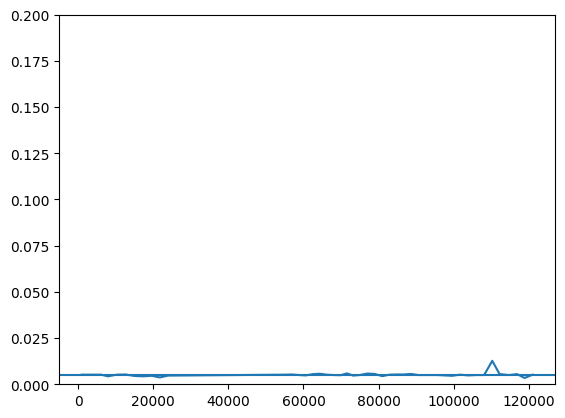

In [6]:
plt.figure()
plt.plot(df_iniciales['force_real'])

plt.axhline(0.005)

plt.ylim(0,0.2)

In [9]:
%matplotlib qt
plt.figure(figsize=(12,6))
plt.plot(df_datos['timestamp_corr'], df_datos['force'], label="Fuerza corregida")

for t in timestamps_ini_corr:
    plt.axvline(t, color='red', alpha=0.6)

for t in timestamps_final_corr:
    plt.axvline(t, color='green', alpha=0.6)

# puntos exactos en las marcas de inicio
plt.scatter(timestamps_ini_corr, df_iniciales['force_real'],
            s=60, marker='o', edgecolor='black', label="Marca Inicial")

plt.axhline(0.2)
plt.axhline(0.005,color='black')
plt.xlabel("Tiempo corregido (millis)")
plt.ylabel("Fuerza (kg)")
plt.title("Fuerza con marcas corregidas")

plt.show()
